# Notebook 03 — Validación de residuales y ajuste con t-Student si rechaza normalidad

En esta etapa se evalúan las propiedades estadísticas de los residuales obtenidos del modelo de Alaton. El objetivo es verificar si el componente estocástico cumple supuestos de:
- media cercana a cero,
- ausencia de autocorrelación,
- y normalidad.

La validación es importante porque muchos modelos climáticos asumen errores Gaussianos. Sin embargo, en datos reales es común encontrar:
- colas pesadas,
- asimetrías,
- y eventos extremos.

En caso de rechazar normalidad, se considera una distribución t-Student para representar mejor la probabilidad de eventos extremos climáticos.

In [37]:
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm

In [38]:
# Leer el excel
df = pd.read_excel('../data/processed/Modelo_Completo.xlsx')

# Renombrar columnas para ajustar a formato requerido
df.rename(
    columns={
        't_min': 'Temperature_Min_C',
        't_max': 'Temperature_Max_C',
        'precip': 'Precipitation_mm',
        'date': 'Date',
        "t_mean": "Temperature_Avg_C",
    },
    inplace=True,
)

# 1. Asegurar que la columna de fecha sea datetime desde el inicio
df['Date'] = pd.to_datetime(df['Date'])

# 2. Filtrar los departamentos seleccionando solo las columnas requeridas y definiendo la fecha como índice
columnas_interes = ['Temperature_Avg_C', 'Temperature_Min_C', 'Temperature_Max_C', 'Precipitation_mm']

df_Casanare = df[df['department'] == 'Casanare'].set_index('Date')[columnas_interes].copy()
df_Tolima   = df[df['department'] == 'Tolima'].set_index('Date')[columnas_interes].copy()

# 3. Ver primeros registros 
print("--- Casanare ---")
print(df_Casanare.head())

print("\n--- Tolima ---")
print(df_Tolima.head())

--- Casanare ---
            Temperature_Avg_C  Temperature_Min_C  Temperature_Max_C  \
Date                                                                  
2010-01-01          10.603952          21.207903                0.0   
2010-01-02          10.214985          20.429970                0.0   
2010-01-03          10.164834          20.329667                0.0   
2010-01-04          10.570606          21.141212                0.0   
2010-01-05          10.787858          21.575716                0.0   

            Precipitation_mm  
Date                          
2010-01-01               0.0  
2010-01-02               0.0  
2010-01-03               0.0  
2010-01-04               0.0  
2010-01-05               0.0  

--- Tolima ---
            Temperature_Avg_C  Temperature_Min_C  Temperature_Max_C  \
Date                                                                  
2010-01-01          10.337388          19.954775               0.72   
2010-01-02           9.932993          

In [39]:
# =============================================================================
# FUNCIÓN UNIFICADA: VALIDACIÓN DE RESIDUALES MULTI-ESCALA TEMPORAL
# =============================================================================
def validar_residuales_alaton(df_dpto, nombre_dpto, frecuencia='diaria'):
    """
    Evalúa las propiedades estadísticas y la validez del supuesto de normalidad
    sobre los residuales del modelo Alaton en diferentes escalas temporales.
    
    Opciones de frecuencia: 'diaria', 'mensual', 'trimestral', 'semestral', 'anual'
    """
    # Mapeo de frecuencias amigables a códigos oficiales de pandas resample (2026+)
    mapa_frecuencias = {
        'diaria': 'D',
        'mensual': 'ME',
        'trimestral': 'QE',
        'semestral': '6ME',
        'anual': 'YE'
    }
    
    frec_code = mapa_frecuencias.get(frecuencia.lower())
    if frec_code is None:
        raise ValueError("Frecuencia no válida. Elige entre: 'diaria', 'mensual', 'trimestral', 'semestral', 'anual'")
        
    print(f"\n" + "="*75)
    print(f" VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES ({frecuencia.upper()}): {nombre_dpto.upper()}")
    print("="*75)
    
    temp = df_dpto.copy()
    
    # 1. Reconstrucción del ajuste estacional diario base
    temp['T_avg_calc'] = (temp['Temperature_Max_C'] + temp['Temperature_Min_C']) / 2
    dia_del_ano = temp.index.dayofyear
    temp['sin'] = np.sin(2 * np.pi * dia_del_ano / 365)
    temp['cos'] = np.cos(2 * np.pi * dia_del_ano / 365)
    
    y = temp['T_avg_calc']
    X = sm.add_constant(temp[['sin', 'cos']])
    
    model = sm.OLS(y, X).fit()
    temp['residuals'] = y - model.predict(X)
    
    # =============================================================================
    # PASO CLAVE: AGREGACIÓN DE LOS RESIDUALES A LA FRECUENCIA SOLICITADA
    # =============================================================================
    # Al promediar los errores en horizontes más largos, se analiza el comportamiento agregado
    residuals_series = temp['residuals'].resample(frec_code).mean().dropna()

    # =============================================================================
    # PRUEBAS FORMALES DE NORMALIDAD SOBRE LA ESCALA SELECCIONADA
    # =============================================================================
    print(f"\n[1] Pruebas Estadísticas de Normalidad (Escala {frecuencia.capitalize()}):")
    
    # Prueba 1: Jarque-Bera
    jb_stat, jb_p_value = stats.jarque_bera(residuals_series)
    print(f"  - Jarque-Bera: Estadístico = {jb_stat:.4f}, p-valor = {jb_p_value:.4e}")
    
    # Prueba 2: Shapiro-Wilk (Silenciando advertencia de N > 5000 si es diaria)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=UserWarning, message=".*shapiro.*")
        shapiro_stat, shapiro_p_value = stats.shapiro(residuals_series)
    print(f"  - Shapiro-Wilk: Estadístico = {shapiro_stat:.4f}, p-valor = {shapiro_p_value:.4e}")
    
    if jb_p_value < 0.05 or shapiro_p_value < 0.05:
        print(f"\n  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).")
        print(f"      Los residuales agregados presentan colas pesadas o asimetría. Se justifica usar t-Student.")
    else:
        print(f"\n  --> CONCLUSIÓN: No se rechaza la normalidad (p-valor >= 0.05). Los errores son Gaussianos.")

    # =============================================================================
    # AJUSTE DE DISTRIBUCIONES SOBRE LA ESCALA SELECCIONADA
    # =============================================================================
    mu_norm, sigma_norm = stats.norm.fit(residuals_series)
    df_t, loc_t, scale_t = stats.t.fit(residuals_series)
    
    print(f"\n[2] Parámetros de Ajuste Obtenidos ({frecuencia.capitalize()}):")
    print(f"  - Ajuste Normal:    mu = {mu_norm:.4f}, sigma = {sigma_norm:.4f}")
    print(f"  - Ajuste t-Student: df (Grados de libertad) = {df_t:.2f}, loc = {loc_t:.4f}, scale = {scale_t:.4f}")

    # =============================================================================
    # REPORTE GRÁFICO INTEGRADO ADAPTADO
    # =============================================================================
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f'Diagnóstico y Validación de Residuales Históricos ({frecuencia.capitalize()}) — {nombre_dpto}', fontsize=15, fontweight='bold')
    
    ax_hist = plt.subplot2grid((2, 2), (0, 0), rowspan=2)
    ax_qq = plt.subplot2grid((2, 2), (0, 1))
    ax_acf = plt.subplot2grid((2, 2), (1, 1))

    # --- PANEL 1: HISTOGRAMA ---
    ax_hist.hist(residuals_series, bins=60, density=True, alpha=0.4, color='slategrey', label=f'Residuales Promedio {frecuencia.capitalize()}')
    x_axis = np.linspace(residuals_series.min() - 1, residuals_series.max() + 1, 500)
    
    normal_pdf = stats.norm.pdf(x_axis, loc=mu_norm, scale=sigma_norm)
    ax_hist.plot(x_axis, normal_pdf, color='red', lw=2, label=f'Ajuste Normal ($\mu$={mu_norm:.2f}, $\sigma$={sigma_norm:.2f})')
    
    t_pdf = stats.t.pdf(x_axis, df=df_t, loc=loc_t, scale=scale_t)
    ax_hist.plot(x_axis, t_pdf, color='blue', lw=2, ls='--', label=f'Ajuste $t$-Student ($df$={df_t:.1f}, scale={scale_t:.2f})')
    
    ax_hist.set_title(f'Distribución de Frecuencias (Densidad {frecuencia.capitalize()})', fontsize=12, fontweight='bold')
    ax_hist.set_xlabel('Magnitud del Residuo de Temperatura (°C)', fontsize=11)
    ax_hist.set_ylabel('Densidad', fontsize=11)
    ax_hist.grid(True, alpha=0.2)
    ax_hist.legend(loc='upper right', fontsize=10)

    # --- PANEL 2: Q-Q PLOT CON RELACIÓN DE ASPECTO CUADRADA ---
    sm.qqplot(residuals_series, stats.norm, fit=True, line='45', ax=ax_qq, 
              markerfacecolor='slategrey', markeredgecolor='slategrey', alpha=0.5)
    ax_qq.get_lines()[1].set_color('red')
    ax_qq.get_lines()[1].set_linewidth(1.5)
    ax_qq.set_box_aspect(1) 
    ax_qq.set_title(f'Gráfico Cuantil-Cuantil (Q-Q Plot vs Normal)', fontsize=12, fontweight='bold')
    ax_qq.set_xlabel('Cuantiles Teóricos Gaussianos', fontsize=10)
    ax_qq.set_ylabel('Cuantiles Empíricos de la Muestra', fontsize=10)
    ax_qq.grid(True, alpha=0.2)

    # --- PANEL 3: ACF (Ajuste automático de lags según volumen de datos) ---
    max_lags = min(30, len(residuals_series) // 4)
    plot_acf(residuals_series, ax=ax_acf, lags=max_lags, color='steelblue', vlines_kwargs={"colors": 'steelblue', "linewidth": 1.2})
    ax_acf.set_title(f'Función de Autocorrelación Temporal (ACF — Próximos {max_lags} Rezagos)', fontsize=12, fontweight='bold')
    ax_acf.set_xlabel(f'Rezago Temporal (Lags en Periodos)', fontsize=10)
    ax_acf.set_ylabel('Coeficiente de Correlación', fontsize=10)
    ax_acf.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()
    
    dict_resultados = {
        'normal_params': (mu_norm, sigma_norm),
        't_params': (df_t, loc_t, scale_t),
        'rechaza_normalidad': (jb_p_value < 0.05),
        'frecuencia_evaluada': frecuencia
    }
    return dict_resultados


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES (DIARIA): CASANARE

[1] Pruebas Estadísticas de Normalidad (Escala Diaria):
  - Jarque-Bera: Estadístico = 21751.3221, p-valor = 0.0000e+00
  - Shapiro-Wilk: Estadístico = 0.8160, p-valor = 3.2296e-63

  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).
      Los residuales agregados presentan colas pesadas o asimetría. Se justifica usar t-Student.

[2] Parámetros de Ajuste Obtenidos (Diaria):
  - Ajuste Normal:    mu = 0.0000, sigma = 4.6921
  - Ajuste t-Student: df (Grados de libertad) = 1.79, loc = -1.2350, scale = 2.0886


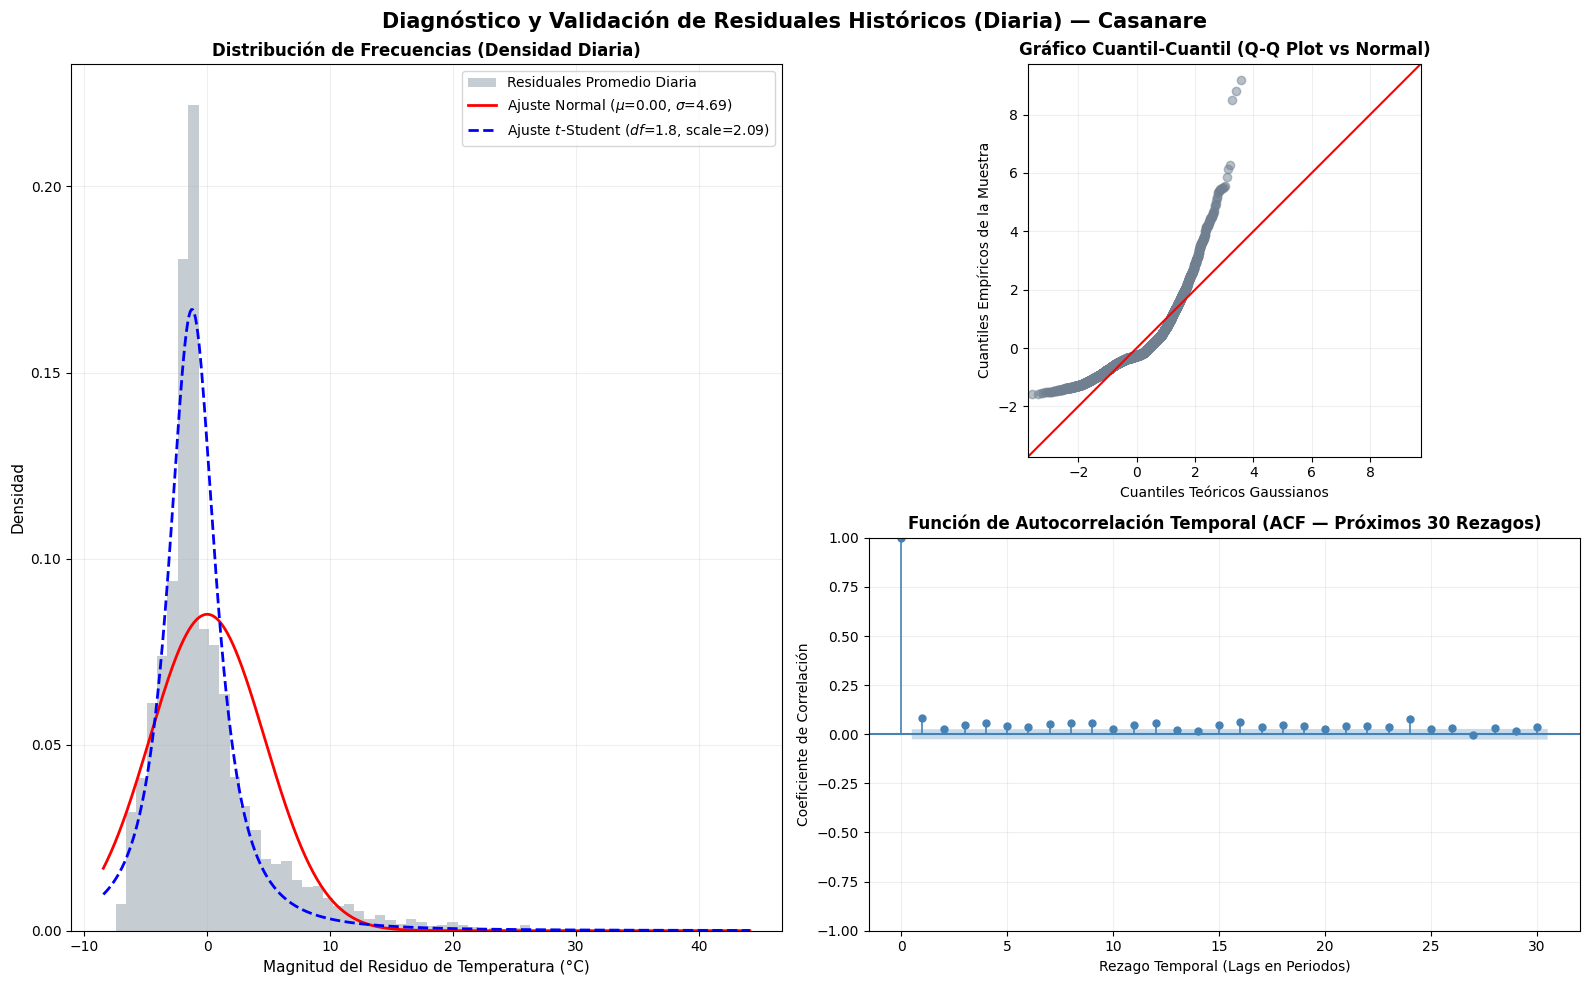


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES (TRIMESTRAL): CASANARE

[1] Pruebas Estadísticas de Normalidad (Escala Trimestral):
  - Jarque-Bera: Estadístico = 3.5542, p-valor = 1.6913e-01
  - Shapiro-Wilk: Estadístico = 0.9513, p-valor = 1.3299e-02

  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).
      Los residuales agregados presentan colas pesadas o asimetría. Se justifica usar t-Student.

[2] Parámetros de Ajuste Obtenidos (Trimestral):
  - Ajuste Normal:    mu = -0.0011, sigma = 0.9711
  - Ajuste t-Student: df (Grados de libertad) = 11001871366620.20, loc = -0.0011, scale = 0.9711


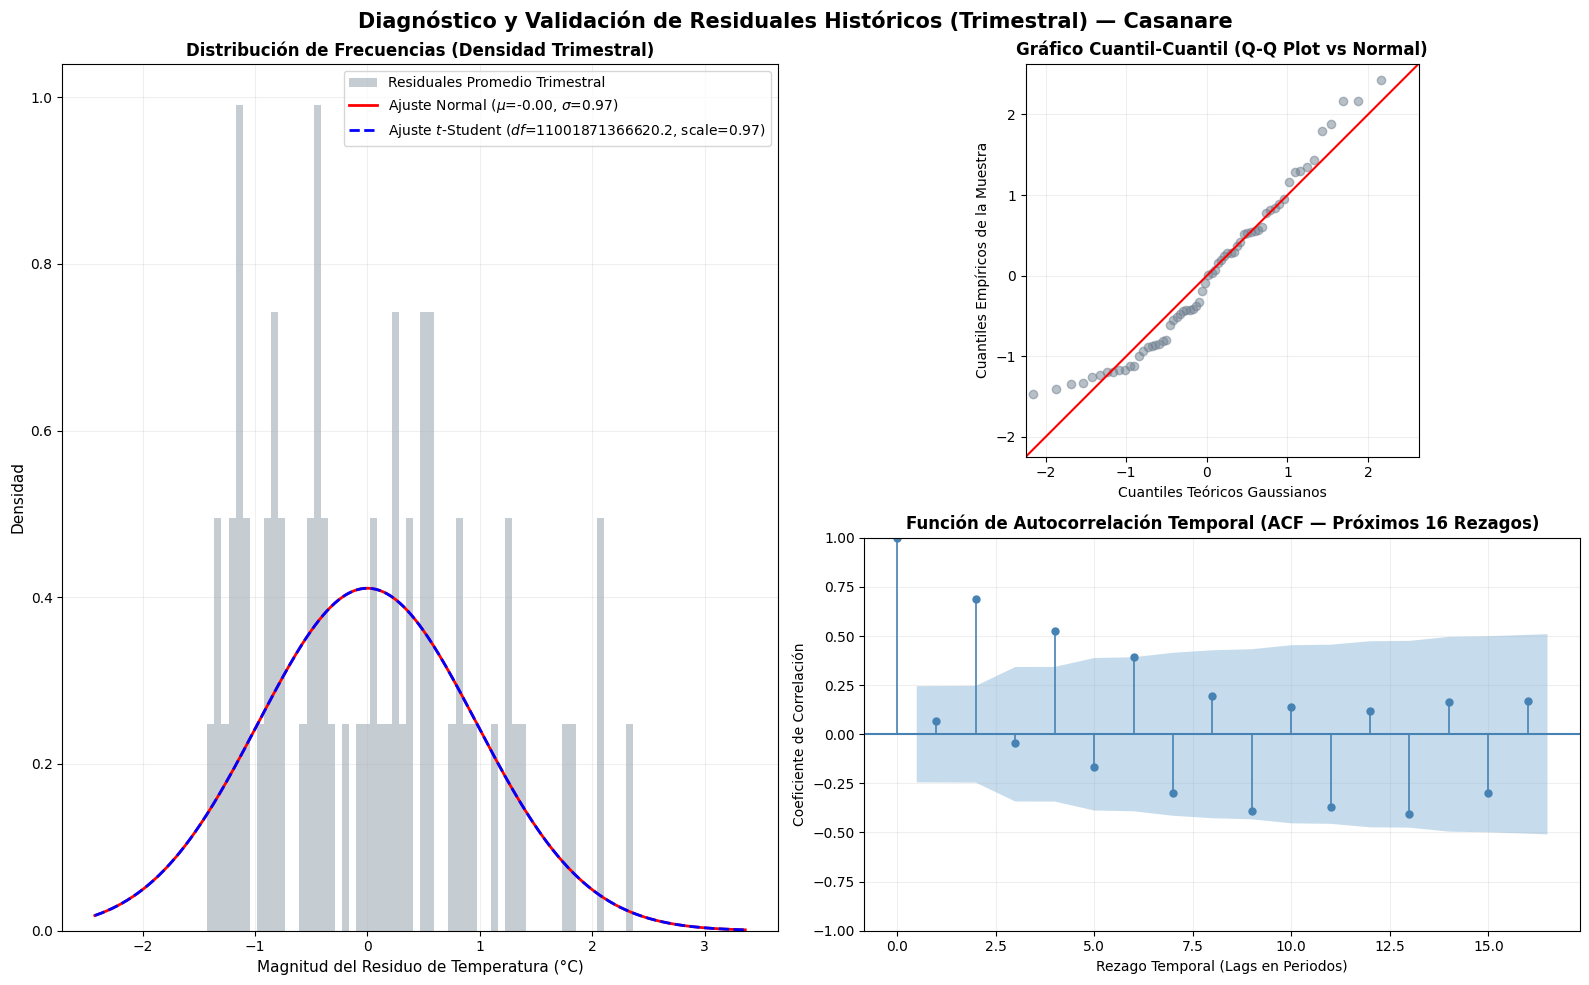


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES (MENSUAL): CASANARE

[1] Pruebas Estadísticas de Normalidad (Escala Mensual):
  - Jarque-Bera: Estadístico = 9.5979, p-valor = 8.2384e-03
  - Shapiro-Wilk: Estadístico = 0.9768, p-valor = 2.8192e-03

  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).
      Los residuales agregados presentan colas pesadas o asimetría. Se justifica usar t-Student.

[2] Parámetros de Ajuste Obtenidos (Mensual):
  - Ajuste Normal:    mu = -0.0007, sigma = 1.3213
  - Ajuste t-Student: df (Grados de libertad) = 343.69, loc = -0.0028, scale = 1.3175


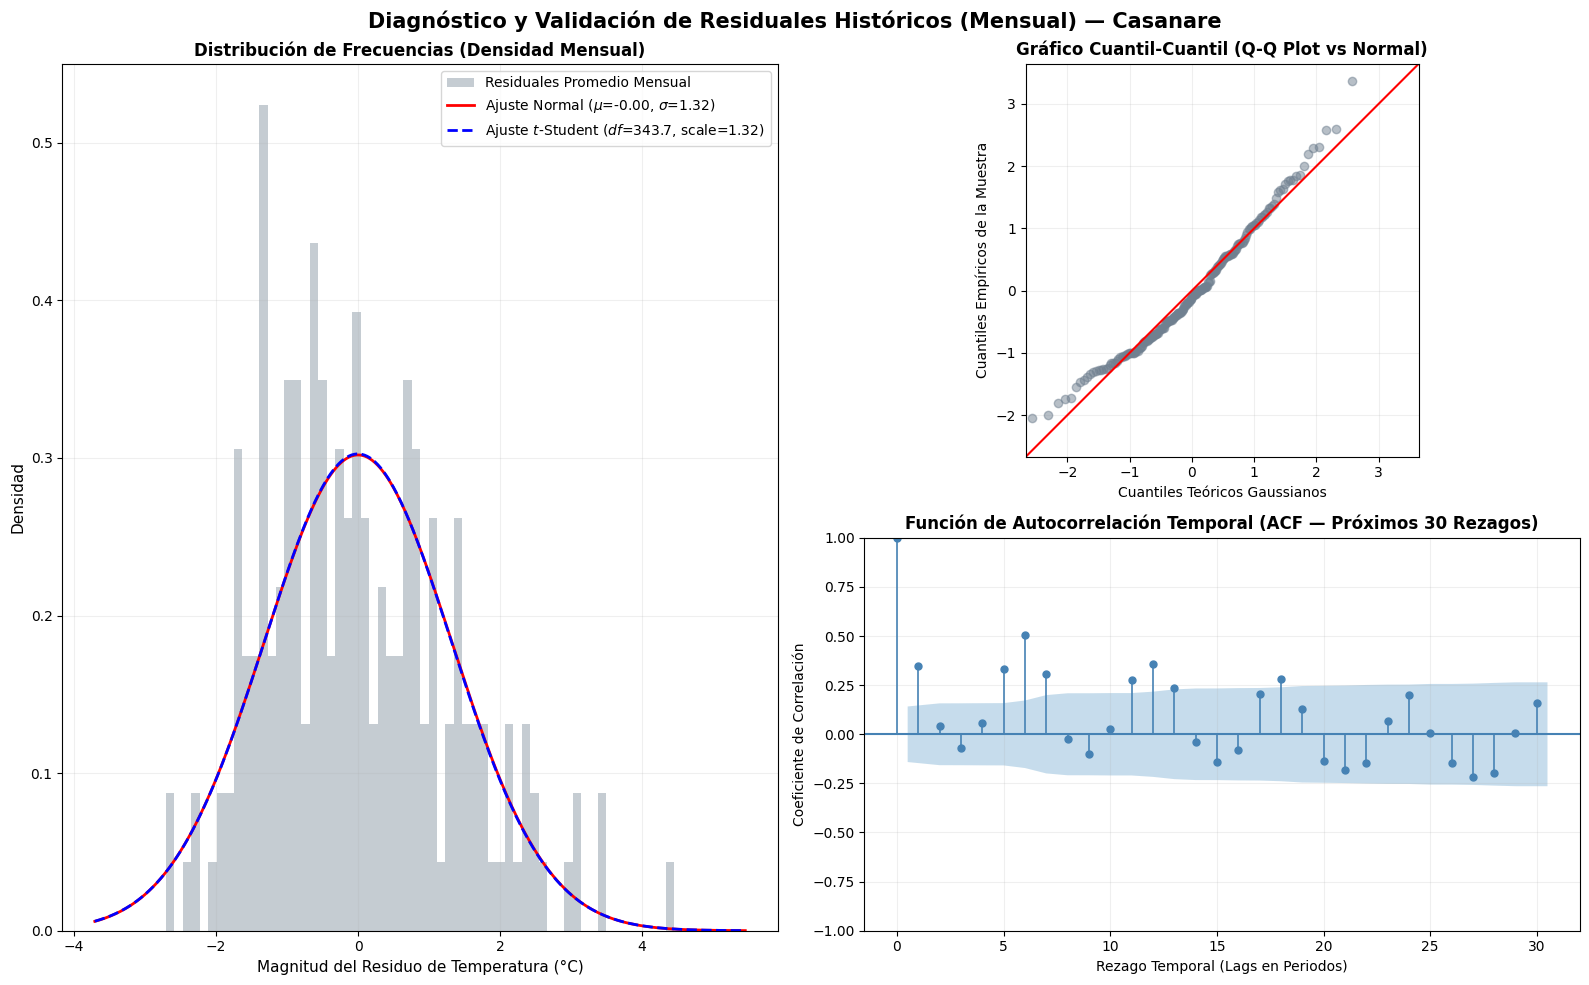


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES (SEMESTRAL): CASANARE

[1] Pruebas Estadísticas de Normalidad (Escala Semestral):
  - Jarque-Bera: Estadístico = 7.5450, p-valor = 2.2994e-02
  - Shapiro-Wilk: Estadístico = 0.8922, p-valor = 3.3674e-03

  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).
      Los residuales agregados presentan colas pesadas o asimetría. Se justifica usar t-Student.

[2] Parámetros de Ajuste Obtenidos (Semestral):
  - Ajuste Normal:    mu = -0.0371, sigma = 0.7522
  - Ajuste t-Student: df (Grados de libertad) = 1.75, loc = -0.2038, scale = 0.3703


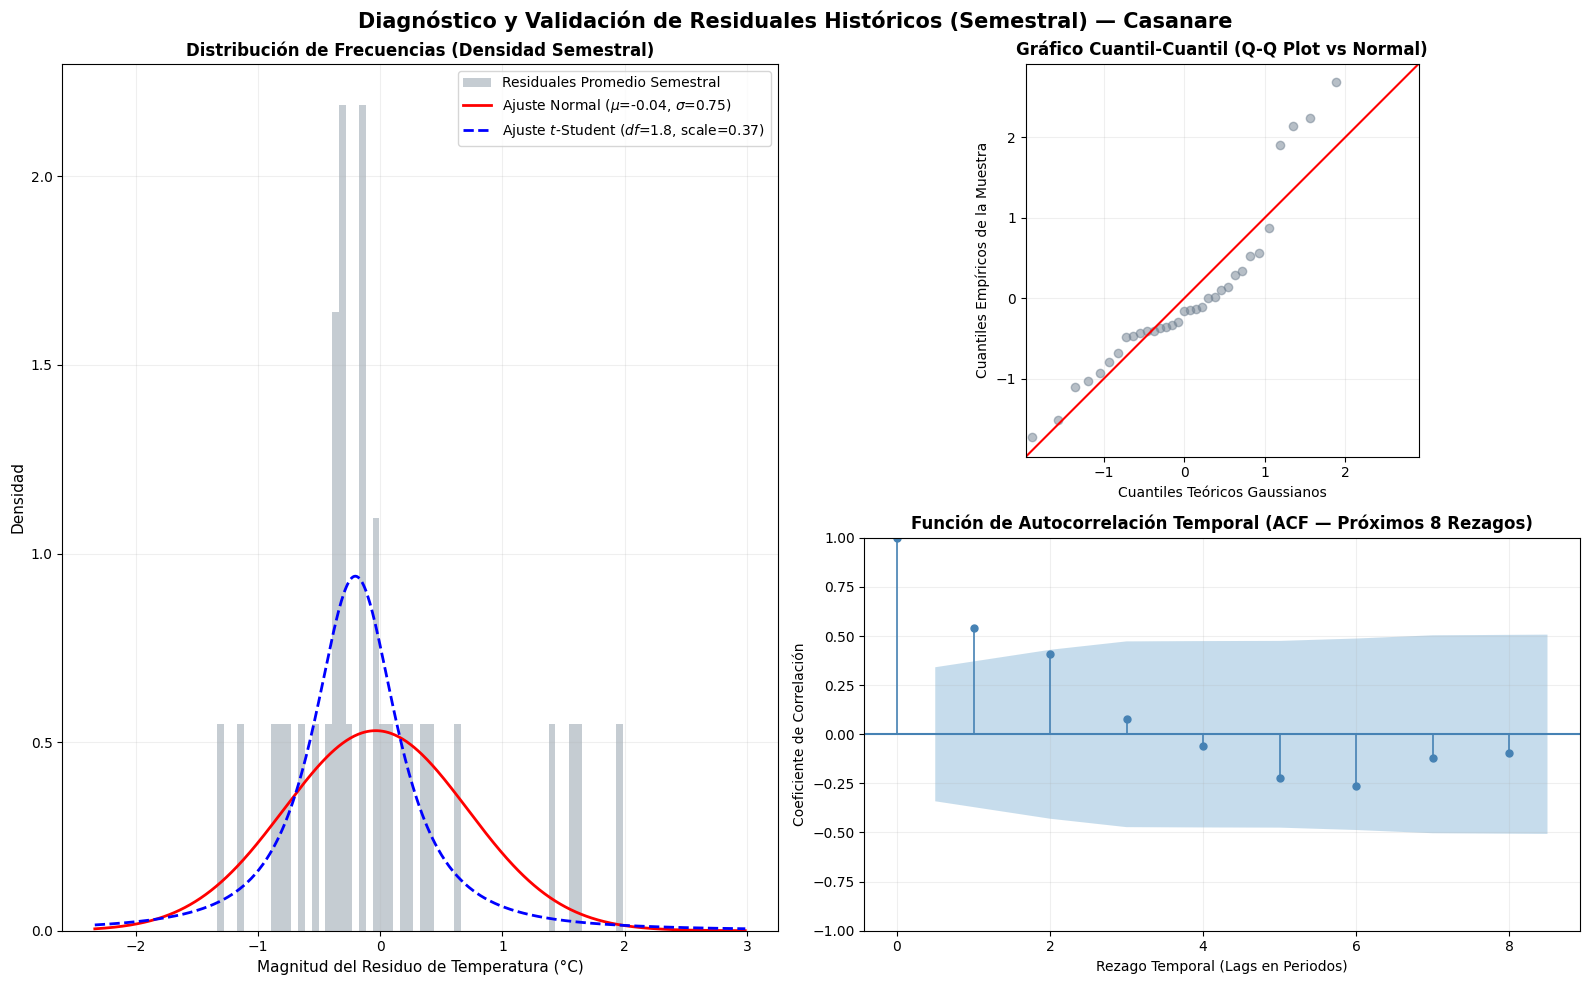


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES (DIARIA): TOLIMA

[1] Pruebas Estadísticas de Normalidad (Escala Diaria):
  - Jarque-Bera: Estadístico = 11247.0956, p-valor = 0.0000e+00
  - Shapiro-Wilk: Estadístico = 0.7769, p-valor = 5.6029e-67

  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).
      Los residuales agregados presentan colas pesadas o asimetría. Se justifica usar t-Student.

[2] Parámetros de Ajuste Obtenidos (Diaria):
  - Ajuste Normal:    mu = 0.0000, sigma = 3.6665
  - Ajuste t-Student: df (Grados de libertad) = 1.41, loc = -1.5381, scale = 1.3661


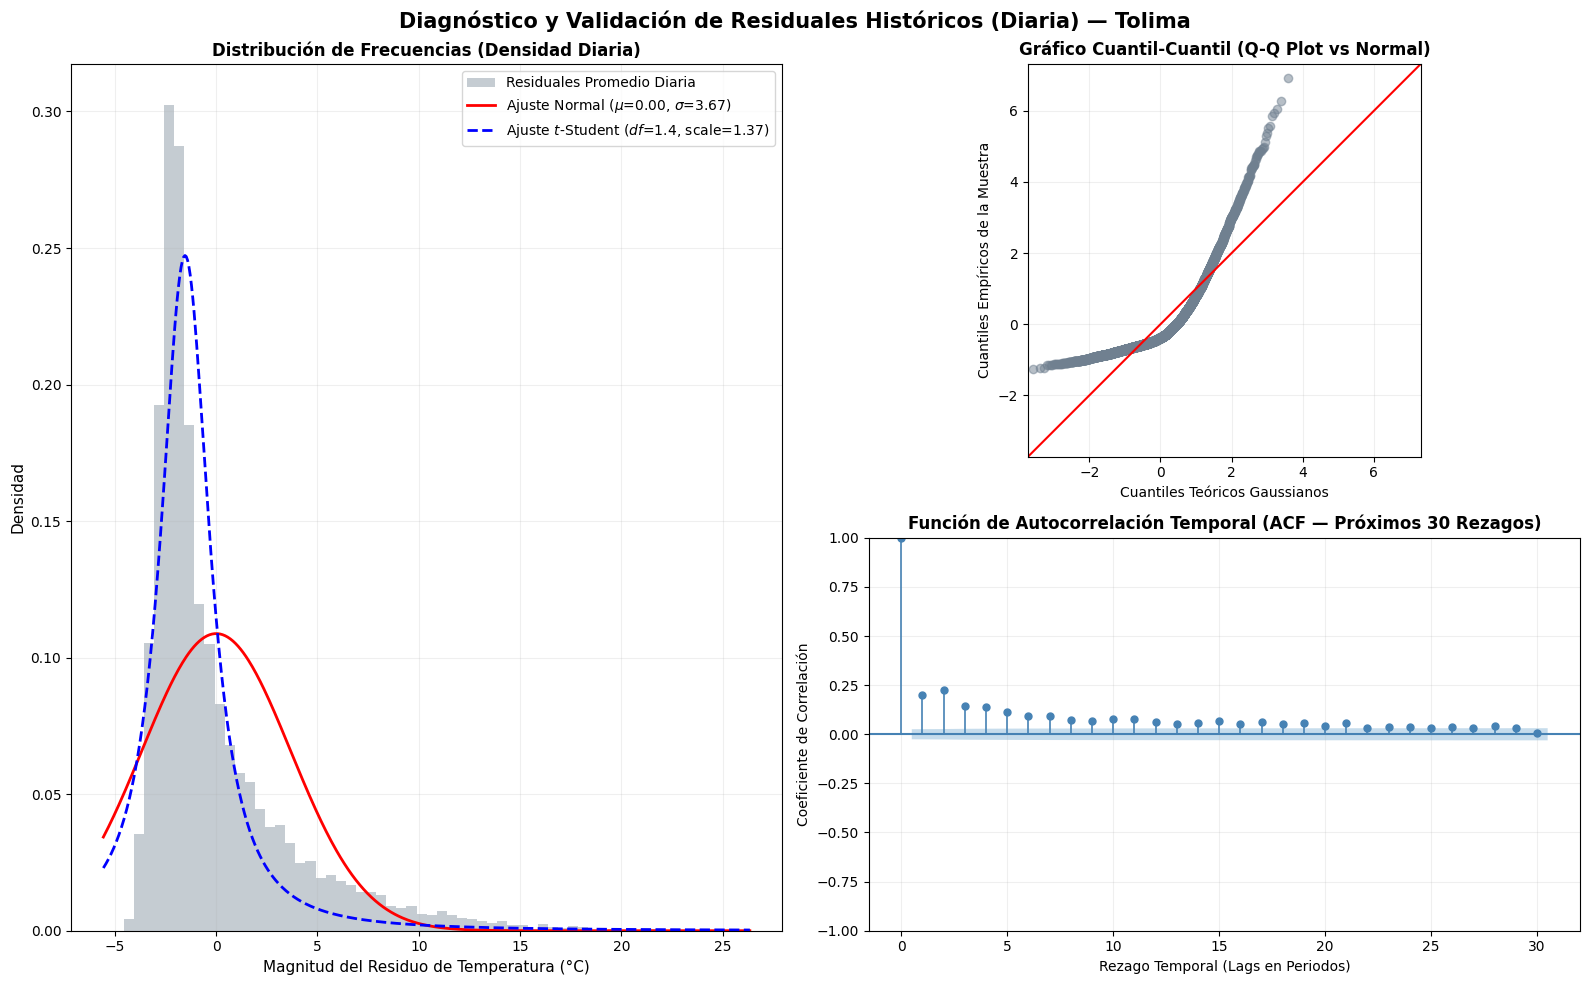


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES (MENSUAL): TOLIMA

[1] Pruebas Estadísticas de Normalidad (Escala Mensual):
  - Jarque-Bera: Estadístico = 4.8329, p-valor = 8.9238e-02
  - Shapiro-Wilk: Estadístico = 0.9825, p-valor = 1.6898e-02

  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).
      Los residuales agregados presentan colas pesadas o asimetría. Se justifica usar t-Student.

[2] Parámetros de Ajuste Obtenidos (Mensual):
  - Ajuste Normal:    mu = 0.0000, sigma = 1.3258
  - Ajuste t-Student: df (Grados de libertad) = 8289156411.36, loc = 0.0000, scale = 1.3258


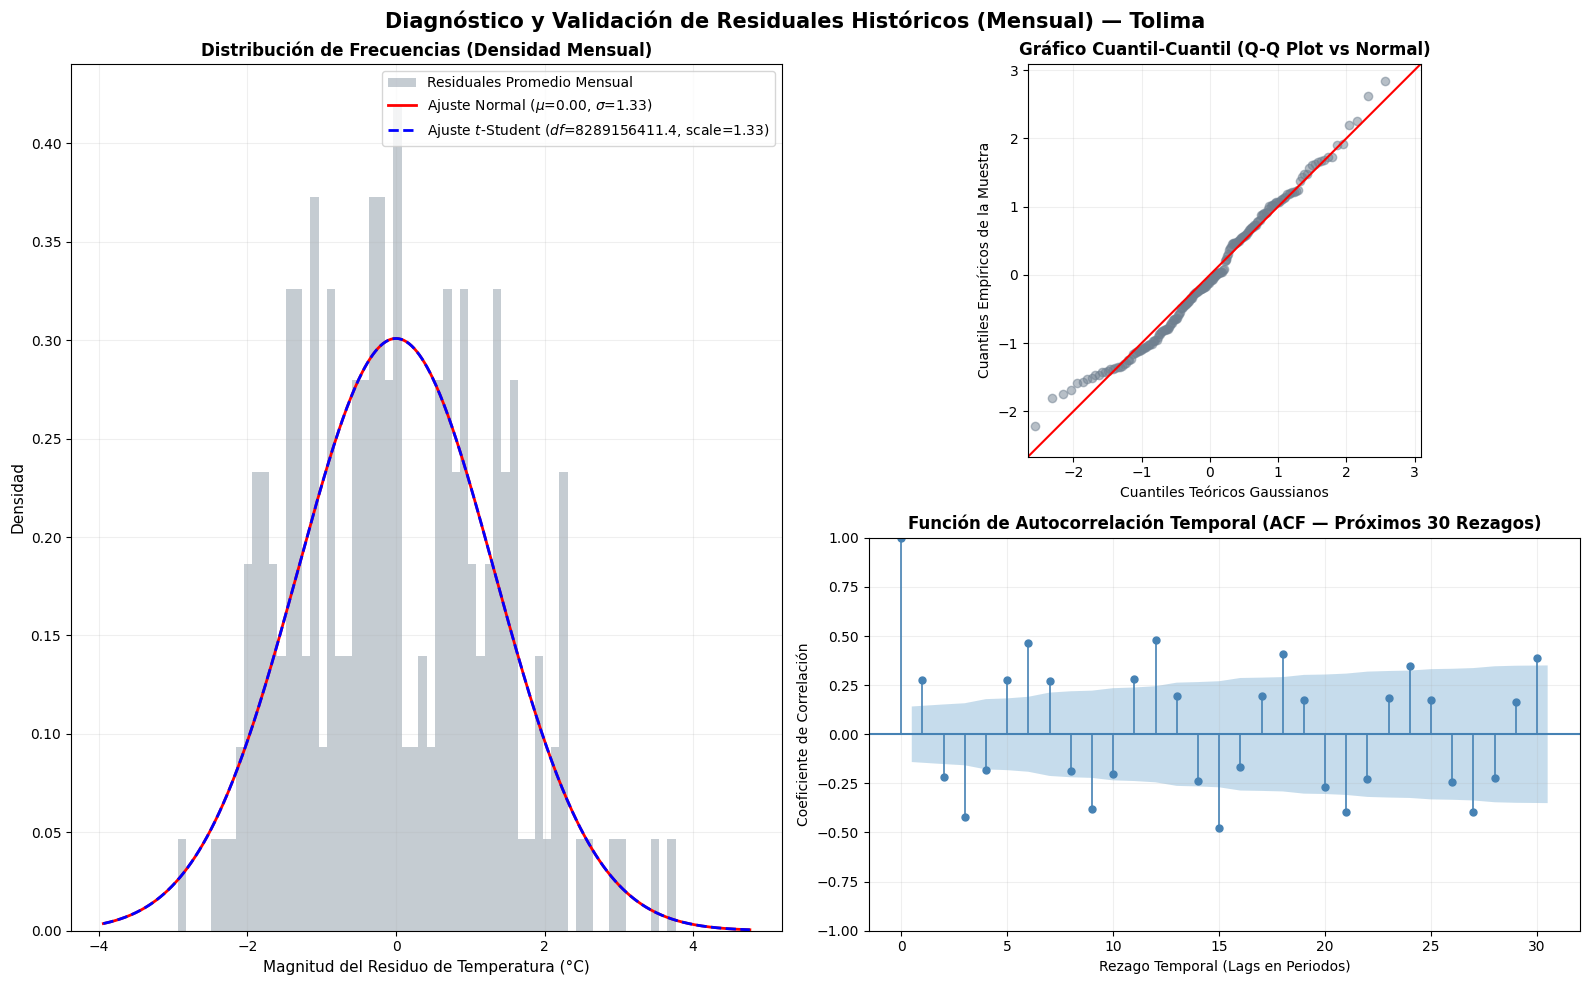


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES (TRIMESTRAL): TOLIMA

[1] Pruebas Estadísticas de Normalidad (Escala Trimestral):
  - Jarque-Bera: Estadístico = 1.9889, p-valor = 3.6993e-01
  - Shapiro-Wilk: Estadístico = 0.9775, p-valor = 2.9075e-01

  --> CONCLUSIÓN: No se rechaza la normalidad (p-valor >= 0.05). Los errores son Gaussianos.

[2] Parámetros de Ajuste Obtenidos (Trimestral):
  - Ajuste Normal:    mu = -0.0014, sigma = 0.8760
  - Ajuste t-Student: df (Grados de libertad) = 635392427421.20, loc = -0.0014, scale = 0.8760


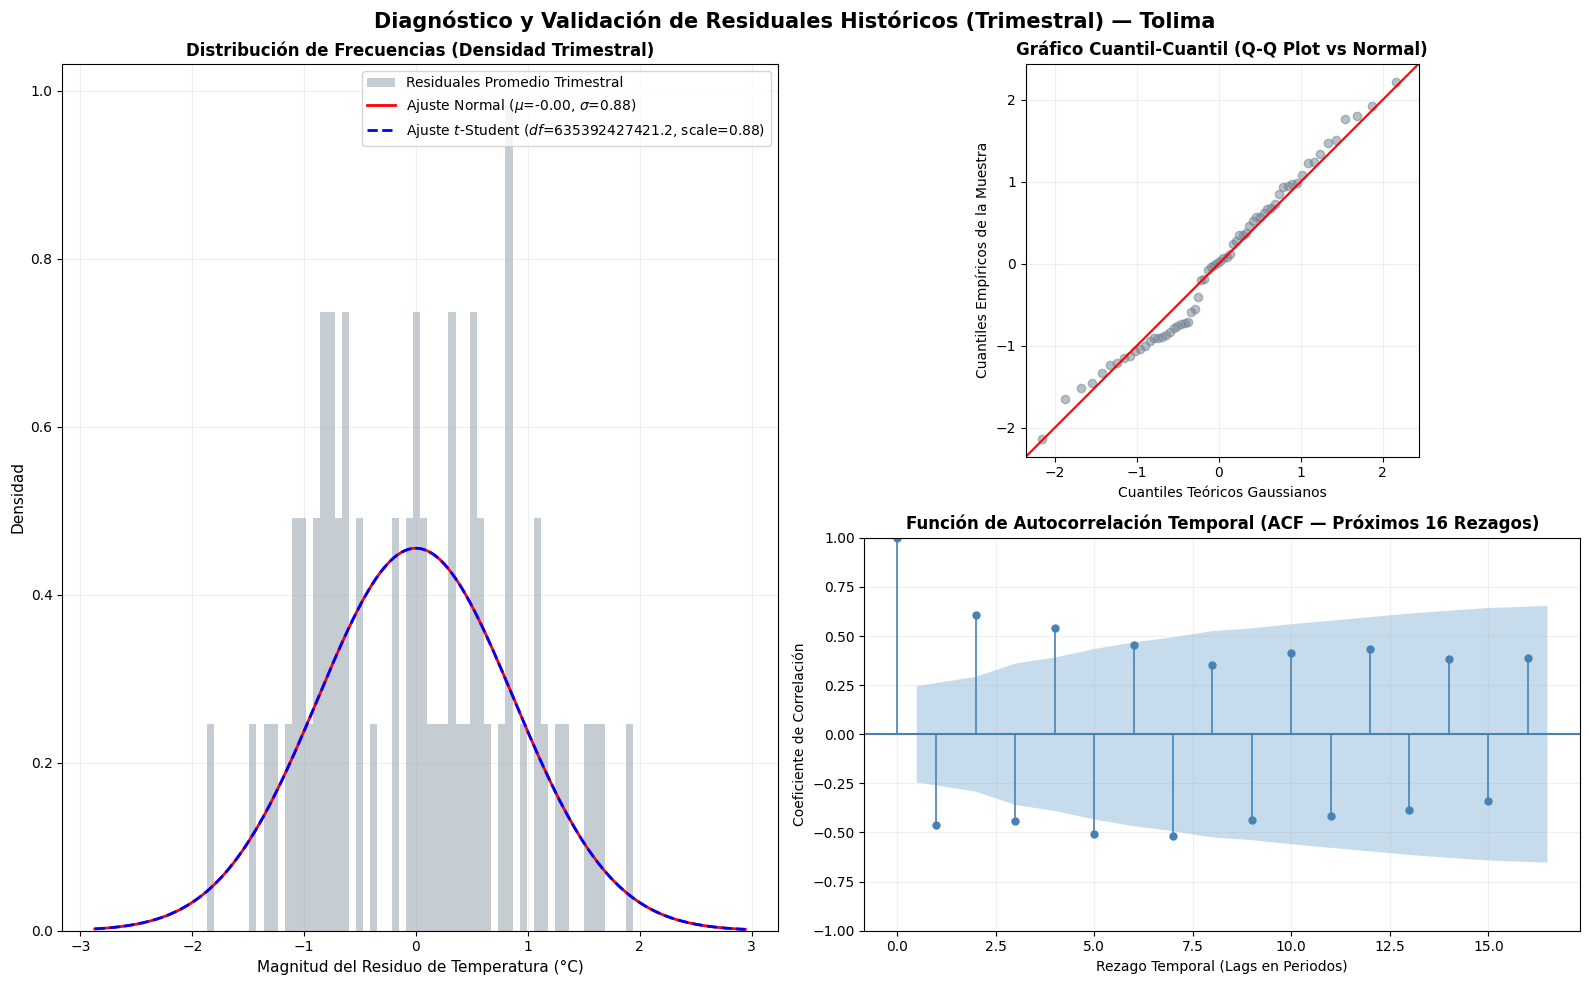


 VALIDACIÓN DE RESIDUALES Y DISTRIBUCIONES (SEMESTRAL): TOLIMA

[1] Pruebas Estadísticas de Normalidad (Escala Semestral):
  - Jarque-Bera: Estadístico = 16.4224, p-valor = 2.7159e-04
  - Shapiro-Wilk: Estadístico = 0.9277, p-valor = 3.0179e-02

  --> CONCLUSIÓN: Se RECHAZA la hipótesis nula de normalidad (p-valor < 0.05).
      Los residuales agregados presentan colas pesadas o asimetría. Se justifica usar t-Student.

[2] Parámetros de Ajuste Obtenidos (Semestral):
  - Ajuste Normal:    mu = -0.0510, sigma = 0.5849
  - Ajuste t-Student: df (Grados de libertad) = 2.95, loc = -0.0089, scale = 0.3736


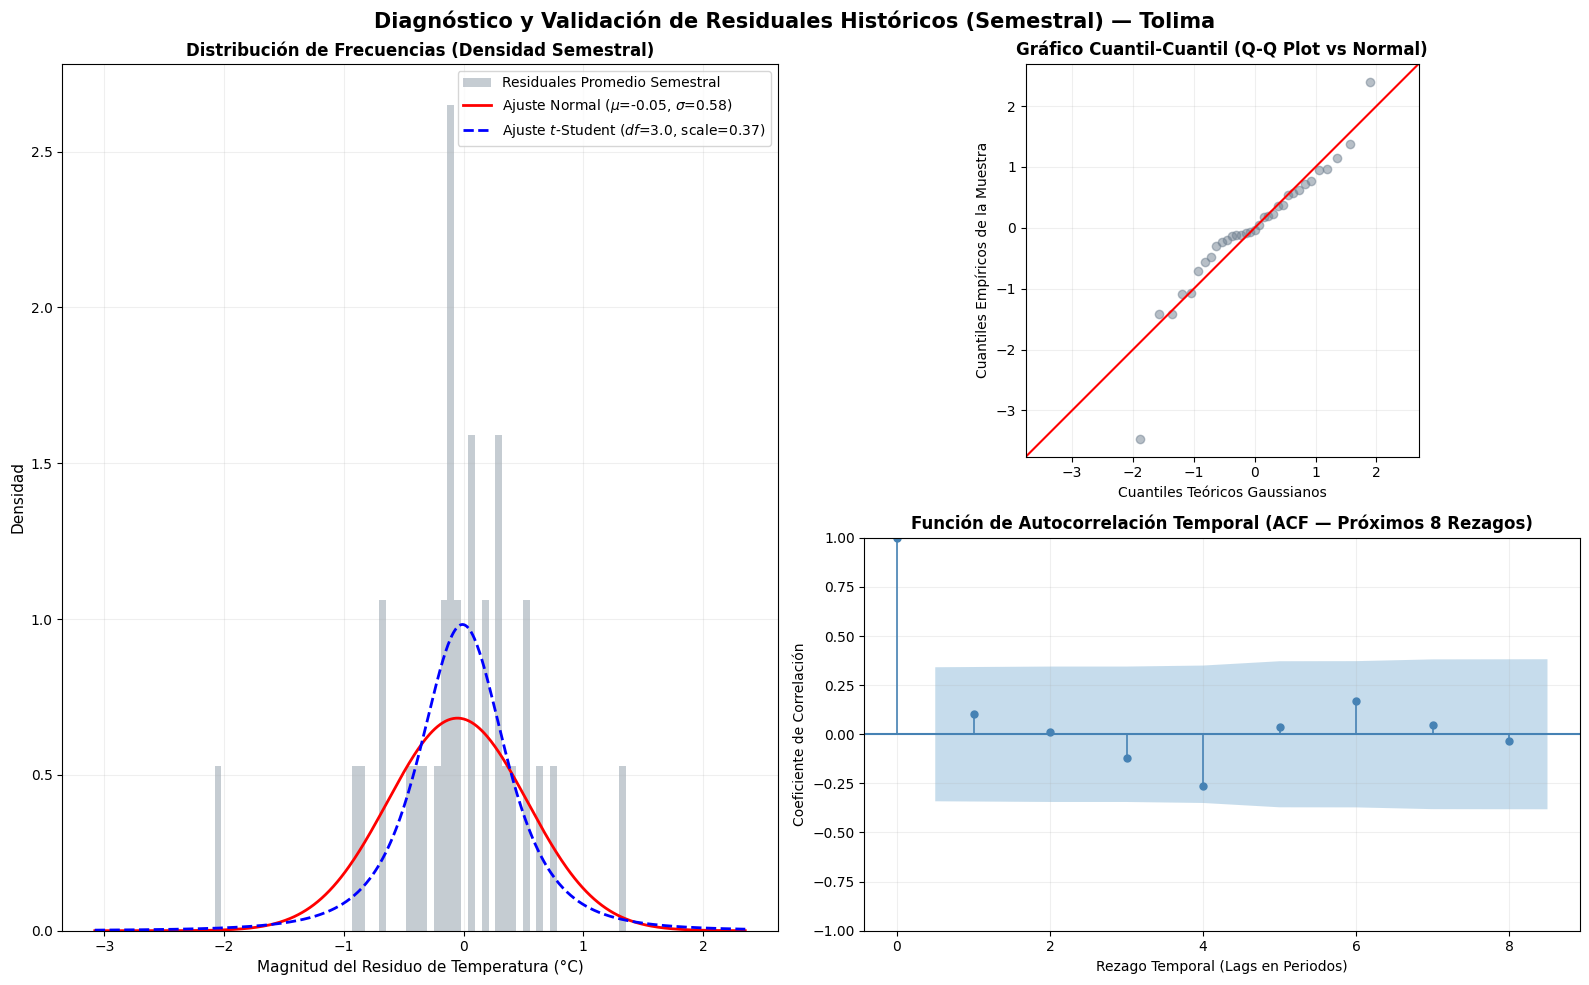

In [40]:
# Caso 1: Validación Diaria tradicional para verificar colas pesadas originales
res_diarios = validar_residuales_alaton(df_Casanare, "Casanare", frecuencia='diaria')

# Caso 2: Validación Trimestral para evaluar comportamiento agregado a corto plazo
res_trimestrales = validar_residuales_alaton(df_Casanare, "Casanare", frecuencia='trimestral')

# Caso 3: Validación Mensual para Casanare
res_mensuales = validar_residuales_alaton(df_Casanare, "Casanare", frecuencia='mensual')

# Caso 4: Validación Semestral para Casanare
res_semestrales = validar_residuales_alaton(df_Casanare, "Casanare", frecuencia='semestral')

# Caso 5: Validación diaria para Tolima
res_diarios_tol = validar_residuales_alaton(df_Tolima, "Tolima", frecuencia='diaria')

# Caso 6: Validación mensual para Tolima
res_mensuales_tol = validar_residuales_alaton(df_Tolima, "Tolima", frecuencia='mensual')

# Caso 7: Validación Trimestral para Tolima
res_trimestrales_tol = validar_residuales_alaton(df_Tolima, "Tolima", frecuencia='trimestral')

# Caso 8: Validación Semestral para Tolima
res_semestrales_tol = validar_residuales_alaton(df_Tolima, "Tolima", frecuencia='semestral')
